In [1]:
import kagglehub
path = kagglehub.dataset_download("vijayaragulvr/flood-prediction")

100%|██████████| 195k/195k [00:00<00:00, 41.5MB/s]

Extracting files...


--- Step 1: Loading Dataset ---


Saving flood_dataset_classification.csv to flood_dataset_classification (1).csv
Dataset successfully loaded. Shape: 6237 rows, 12 columns.

--- Step 2: Data Overview & Integrity Audit ---

--- Data Structure & Types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6237 entries, 0 to 6236
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Disaster Type   6237 non-null   int64  
 1   Latitude        6237 non-null   float64
 2   Longitude       6237 non-null   float64
 3   Total Deaths    6237 non-null   float64
 4   Total Affected  6237 non-null   float64
 5   duration        6237 non-null   float64
 6   time            6237 non-null   int64  
 7   Rainfall        6237 non-null   float64
 8   Elevation       6237 non-null   float64
 9   Slope           6237 non-null   float64
 10  distance        6237 non-null   float64
 11  occured         6237 non-null   int64  
dtypes: float64(9), int64(3)
memory usage: 

,Disaster Type,Latitude,Longitude,Total Deaths,Total Affected,duration,time,Rainfall,Elevation,Slope,distance,occured
0,0,52.6717,-0.2995,300.0,3000.0,0.0,1900,1383.125626,11.0,1.788207,0.0,1
1,0,35.6897,139.6920,1379.0,13790.0,0.0,1909,1383.125626,49.0,24.356508,0.0,1
2,0,39.9050,116.3910,100000.0,1000000.0,0.0,1909,580.345856,55.0,8.374380,0.0,1
3,0,23.1288,113.2590,0.0,3000000.0,0.0,1912,2993.401777,7.0,12.917221,0.0,1
4,0,39.1467,117.2060,0.0,635000.0,0.0,1913,1383.125626,3.0,1.513093,0.0,1



--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max
Disaster Type,6237.0,0.773930,1.257769e+00,0.000000,0.000000,0.000000,2.000000,4.000000e+00
Latitude,6237.0,18.767296,2.320592e+01,-53.162569,4.868178,22.704752,37.963000,6.996873e+01
Longitude,6237.0,25.577775,7.547890e+01,-175.273869,-43.415278,30.488437,92.340000,1.798477e+02
Total Deaths,6237.0,3092.210839,7.709807e+04,0.000000,0.000000,8.000000,43.000000,3.700000e+06
Total Affected,6237.0,804754.046978,7.847980e+06,0.000000,500.000000,5381.000000,60016.000000,3.000000e+08
duration,6237.0,25.897066,8.961781e+01,0.000000,0.000000,0.000000,0.000000,6.600000e+02
time,6237.0,1994.058041,2.052214e+01,1900.000000,1987.000000,2000.000000,2008.000000,2.016000e+03
Rainfall,6237.0,1200.677851,1.164591e+03,0.547090,489.270857,1029.113686,1524.737477,2.375195e+04
Elevation,6237.0,604.385537,8.553097e+02,-29.000000,42.000000,239.000000,839.000000,6.796000e+03
Slope,6237.0,7.169169,8.954785e+00,0.000000,1.854334,3.704792,8.656136,6.599135e+01



--- Data Quality Checks ---
Total Missing Values: 0
Duplicate Rows Count: 5


/tmp/ipykernel_1780/575208299.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='occured', ax=axes[0], palette=['#e74c3c', '#2ecc71'])


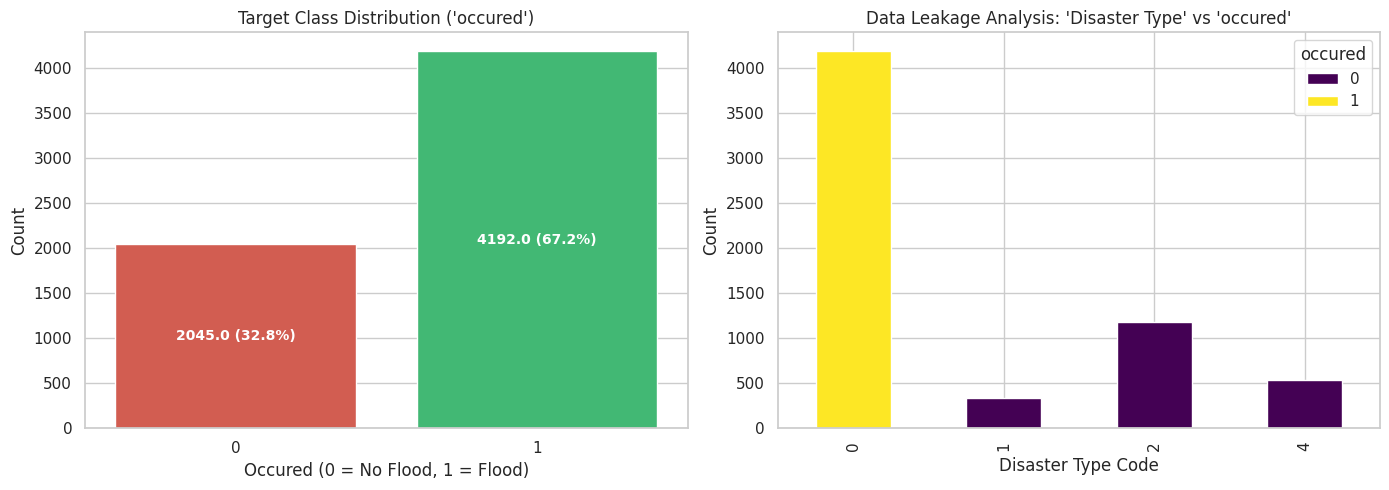

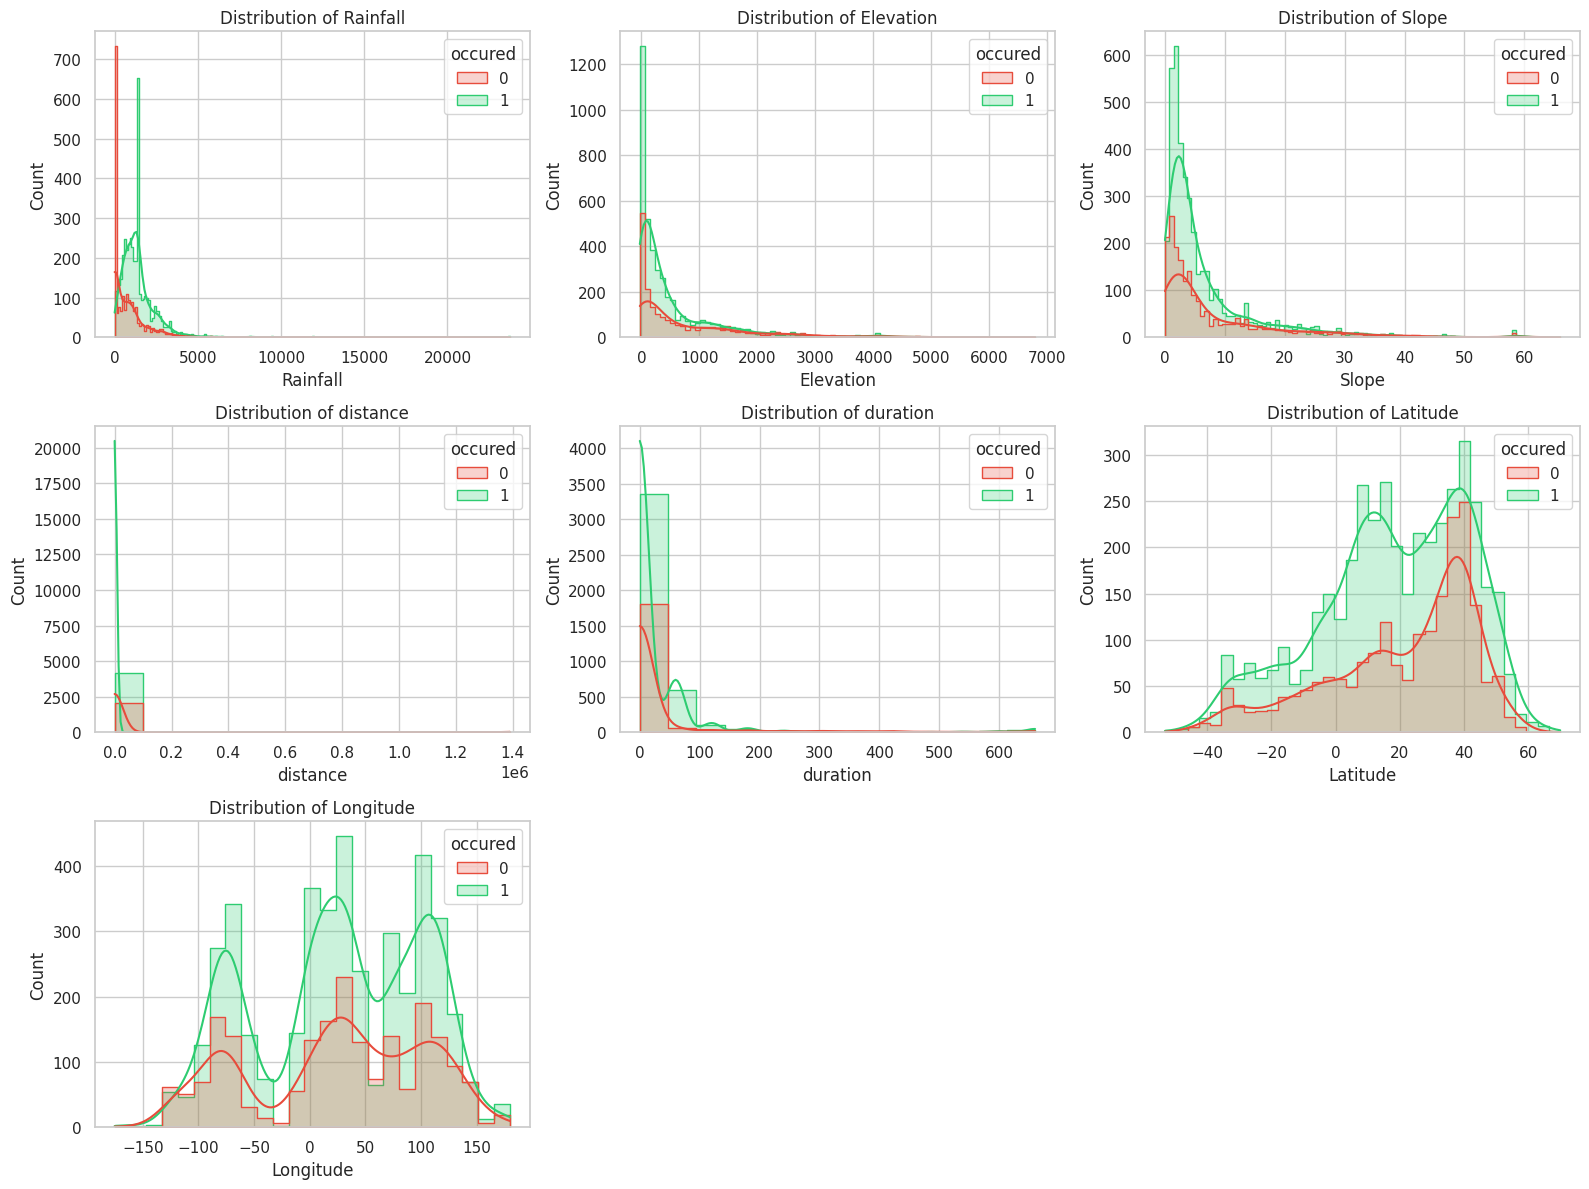

/tmp/ipykernel_1780/575208299.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='occured', palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_1780/575208299.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='occured', palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_1780/575208299.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y=col, x='occured', palette=['#e74c3c', '#2ecc71'])
/tmp/ipykernel_1780/575208299.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

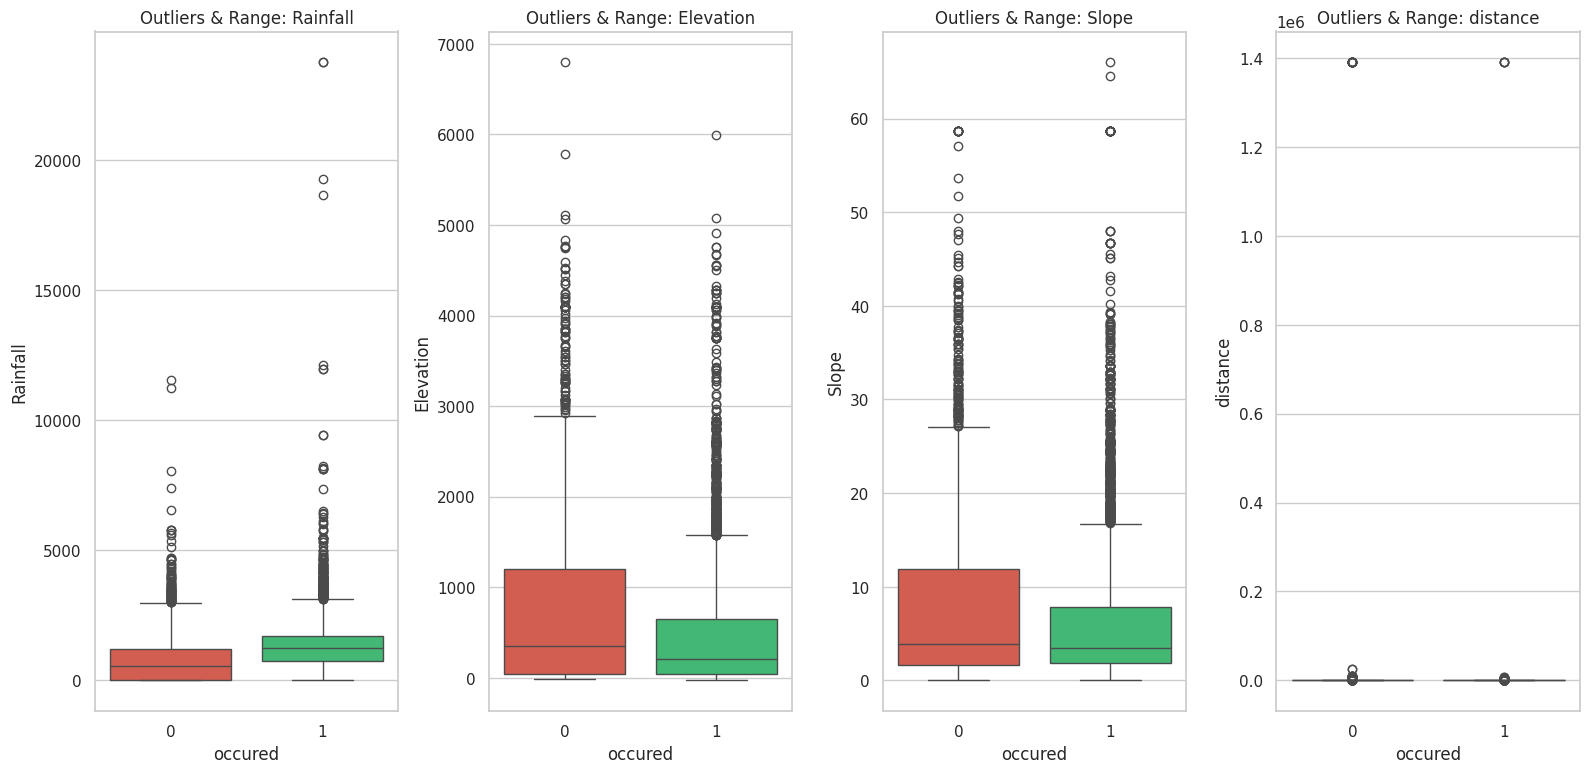

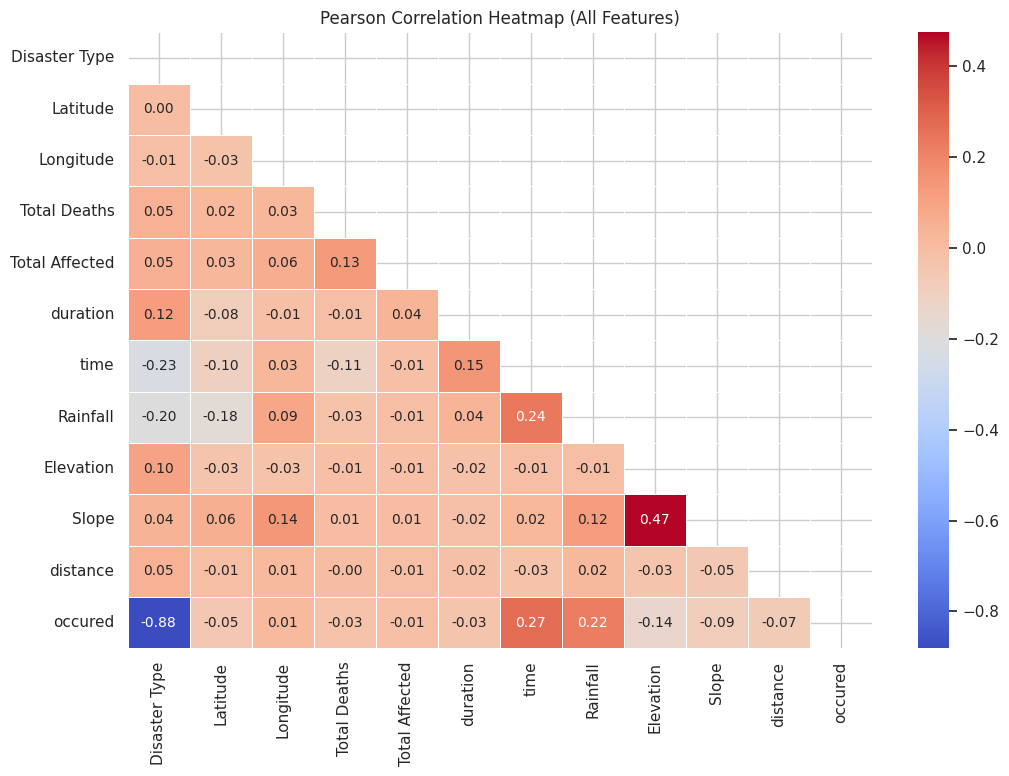


--- Correlation with Target ('occured') ---
occured           1.000000
time              0.269543
Rainfall          0.224318
Longitude         0.012130
Total Affected   -0.010083
Total Deaths     -0.026653
duration         -0.030036
Latitude         -0.048027
distance         -0.067931
Slope            -0.087261
Elevation        -0.138854
Disaster Type    -0.881048
Name: occured, dtype: float64

EDA SUMMARY & MODELING RECOMMENDATIONS
1. Target Leakage: Drop 'Disaster Type' prior to training; it perfectly predicts 'occured'.
2. Post-Event Leakage: Exclude 'Total Deaths' and 'Total Affected' as they are non-causal outputs.
3. Feature Scaling: Apply StandardScaler or RobustScaler due to high skewness in Rainfall, Elevation, and Slope.
4. Core Predictors: 'Rainfall', 'Elevation', 'Slope', 'distance', 'duration', 'Latitude', 'Longitude', and 'time'.


In [8]:
# ==========================================================
# FLOOD RISK CATEGORY CLASSIFICATION - EXPLORATORY DATA ANALYSIS
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# Set aesthetic visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

print("--- Step 1: Loading Dataset ---")
# Upload flood_dataset_classification.csv when prompted if not already in Colab
uploaded = files.upload()
filename = list(uploaded.keys())[0] if uploaded else 'flood_dataset_classification.csv'

df = pd.read_csv(filename)
print(f"Dataset successfully loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# ----------------------------------------------------------
# 1. DATA OVERVIEW & INTEGRITY AUDIT
# ----------------------------------------------------------
print("--- Step 2: Data Overview & Integrity Audit ---")
print("\n--- Data Structure & Types ---")
df.info()

print("\n--- First 5 Rows ---")
display(df.head())

print("\n--- Summary Statistics ---")
display(df.describe().T)

print("\n--- Data Quality Checks ---")
missing_vals = df.isnull().sum().sum()
duplicates = df.duplicated().sum()
print(f"Total Missing Values: {missing_vals}")
print(f"Duplicate Rows Count: {duplicates}")

# ----------------------------------------------------------
# 2. TARGET CLASS DISTRIBUTION & LEAKAGE CHECK
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable (occured) Class Balance
sns.countplot(data=df, x='occured', ax=axes[0], palette=['#e74c3c', '#2ecc71'])
axes[0].set_title("Target Class Distribution ('occured')")
axes[0].set_xlabel("Occured (0 = No Flood, 1 = Flood)")
axes[0].set_ylabel("Count")

for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height} ({height/len(df)*100:.1f}%)',
                     (p.get_x() + p.get_width() / 2., height / 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Data Leakage Cross-Tabulation
pd.crosstab(df['Disaster Type'], df['occured']).plot(kind='bar', stacked=True, ax=axes[1], colormap='viridis')
axes[1].set_title("Data Leakage Analysis: 'Disaster Type' vs 'occured'")
axes[1].set_xlabel("Disaster Type Code")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3. FEATURE DISTRIBUTIONS (HISTOGRAMS & BOX PLOTS)
# ----------------------------------------------------------
features_to_plot = ['Rainfall', 'Elevation', 'Slope', 'distance', 'duration', 'Latitude', 'Longitude']

plt.figure(figsize=(16, 12))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.histplot(data=df, x=col, hue='occured', kde=True, element="step", common_norm=False, palette=['#e74c3c', '#2ecc71'])
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Outlier Analysis via Boxplots
plt.figure(figsize=(16, 8))
for i, col in enumerate(['Rainfall', 'Elevation', 'Slope', 'distance'], 1):
    plt.subplot(1, 4, i)
    sns.boxplot(data=df, y=col, x='occured', palette=['#e74c3c', '#2ecc71'])
    plt.title(f'Outliers & Range: {col}')
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. CORRELATION MATRIX & FEATURE RELEVANCE
# ----------------------------------------------------------
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title("Pearson Correlation Heatmap (All Features)")
plt.show()

# Ranking features by correlation with target (occured)
print("\n--- Correlation with Target ('occured') ---")
corr_target = corr_matrix['occured'].sort_values(ascending=False)
print(corr_target)

# ----------------------------------------------------------
# 5. PREPROCESSING RECOMMENDATIONS BASED ON EDA
# ----------------------------------------------------------
print("\n" + "="*60)
print("EDA SUMMARY & MODELING RECOMMENDATIONS")
print("="*60)
print("1. Target Leakage: Drop 'Disaster Type' prior to training; it perfectly predicts 'occured'.")
print("2. Post-Event Leakage: Exclude 'Total Deaths' and 'Total Affected' as they are non-causal outputs.")
print("3. Feature Scaling: Apply StandardScaler or RobustScaler due to high skewness in Rainfall, Elevation, and Slope.")
print("4. Core Predictors: 'Rainfall', 'Elevation', 'Slope', 'distance', 'duration', 'Latitude', 'Longitude', and 'time'.")

In [9]:
# ==========================================================
# FLOOD RISK CATEGORY CLASSIFICATION - PREPROCESSING PIPELINE
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

print("--- Step 1: Loading Raw Data ---")
df = pd.read_csv('flood_dataset_classification.csv')
print(f"Initial Dataset Shape: {df.shape}")

# ----------------------------------------------------------
# 1. DATA LEAKAGE & RELEVANCE FILTERING
# ----------------------------------------------------------
print("\n--- Step 2: Removing Data Leakage & Non-Predictive Features ---")
# Drop 'Disaster Type' (directly identifies target)
# Drop 'Total Deaths' & 'Total Affected' (post-event impact metrics, not pre-disaster inputs)
leakage_columns = ['Disaster Type', 'Total Deaths', 'Total Affected']
X = df.drop(columns=['occured'] + leakage_columns)
y = df['occured']

print("Features Selected for Modeling:")
for idx, col in enumerate(X.columns, 1):
    print(f"  {idx}. {col}")

# ----------------------------------------------------------
# 2. TRAIN-TEST SPLITTING
# ----------------------------------------------------------
print("\n--- Step 3: Train-Test Split (80/20 Stratified) ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")
print(f"Training Class Ratio (1s): {y_train.mean():.4f}")
print(f"Testing Class Ratio (1s):  {y_test.mean():.4f}")

# ----------------------------------------------------------
# 3. FEATURE SCALING
# ----------------------------------------------------------
print("\n--- Step 4: Applying Standard Scaling ---")
# Fit scaler ONLY on training data to prevent data leakage into test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easy handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

# Save the fitted scaler artifact for Streamlit deployment
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved successfully as 'scaler.pkl'")

# Save preprocessed splits for model training phase
X_train_scaled.to_csv('X_train_scaled.csv', index=False)
X_test_scaled.to_csv('X_test_scaled.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print("\n" + "="*50)
print("PREPROCESSING COMPLETED SUCCESSFULLY!")
print("="*50)

--- Step 1: Loading Raw Data ---
Initial Dataset Shape: (6237, 12)

--- Step 2: Removing Data Leakage & Non-Predictive Features ---
Features Selected for Modeling:
  1. Latitude
  2. Longitude
  3. duration
  4. time
  5. Rainfall
  6. Elevation
  7. Slope
  8. distance

--- Step 3: Train-Test Split (80/20 Stratified) ---
Training set shape: (4989, 8)
Testing set shape:  (1248, 8)
Training Class Ratio (1s): 0.6721
Testing Class Ratio (1s):  0.6723

--- Step 4: Applying Standard Scaling ---
Scaler saved successfully as 'scaler.pkl'

PREPROCESSING COMPLETED SUCCESSFULLY!


--- Step 1: Loading Preprocessed Splits & Scaler ---
Data successfully re-loaded:
  Training samples: 4989 | Testing samples: 1248

--- Step 2: Training Foundational Models ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...

MODEL EVALUATION COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.813301,0.794175,0.974970,0.875334,0.838581
1,Decision Tree,0.780449,0.779426,0.939213,0.851892,0.756625
0,Logistic Regression,0.734776,0.737383,0.940405,0.826611,0.679316


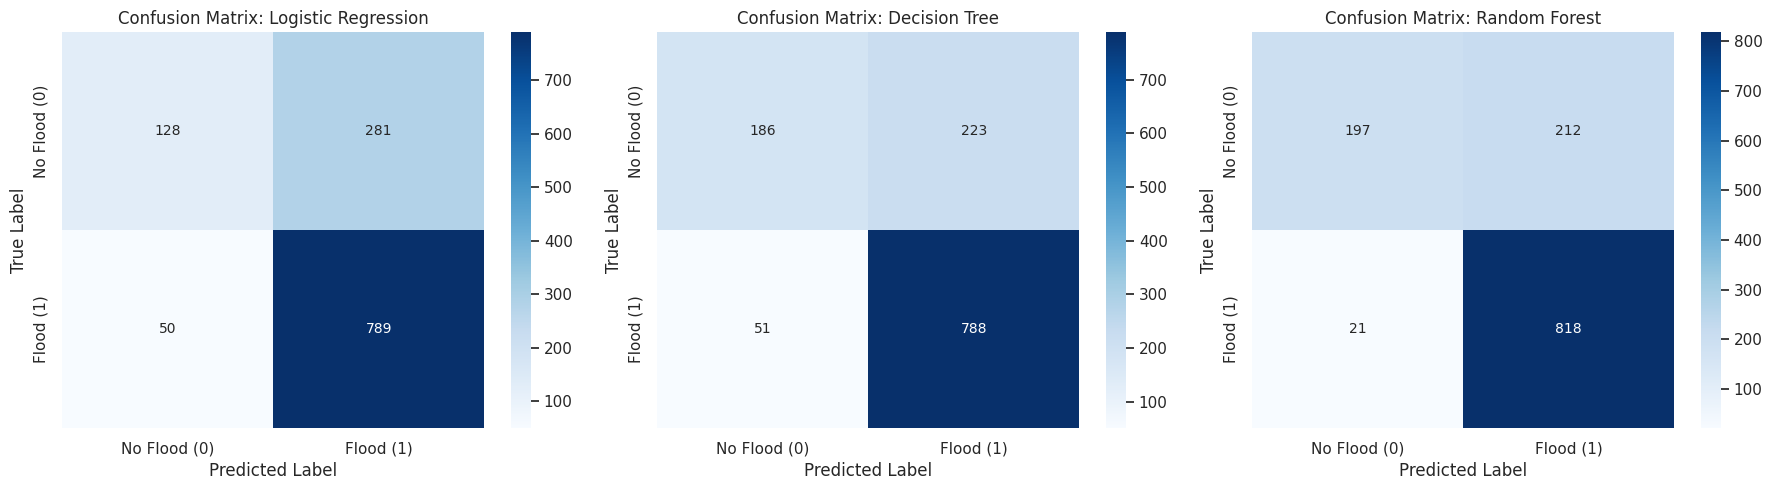

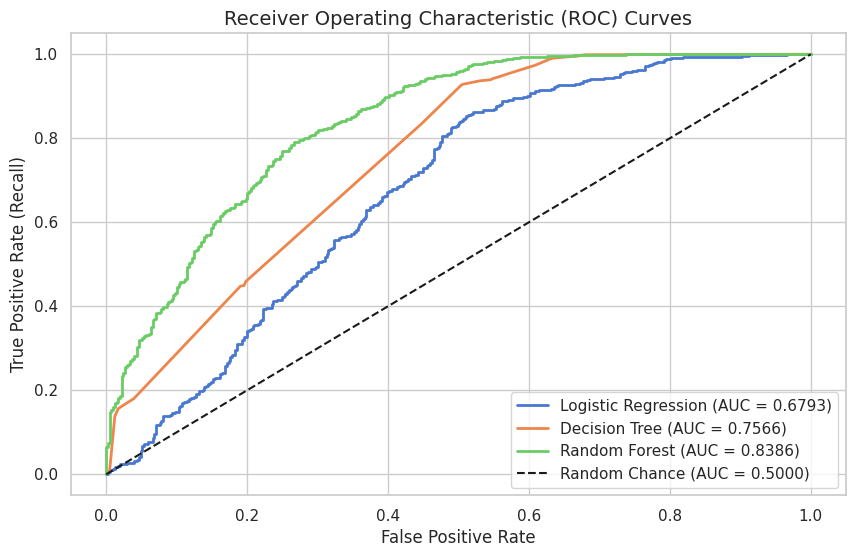


--- Best Performing Model: Random Forest ---


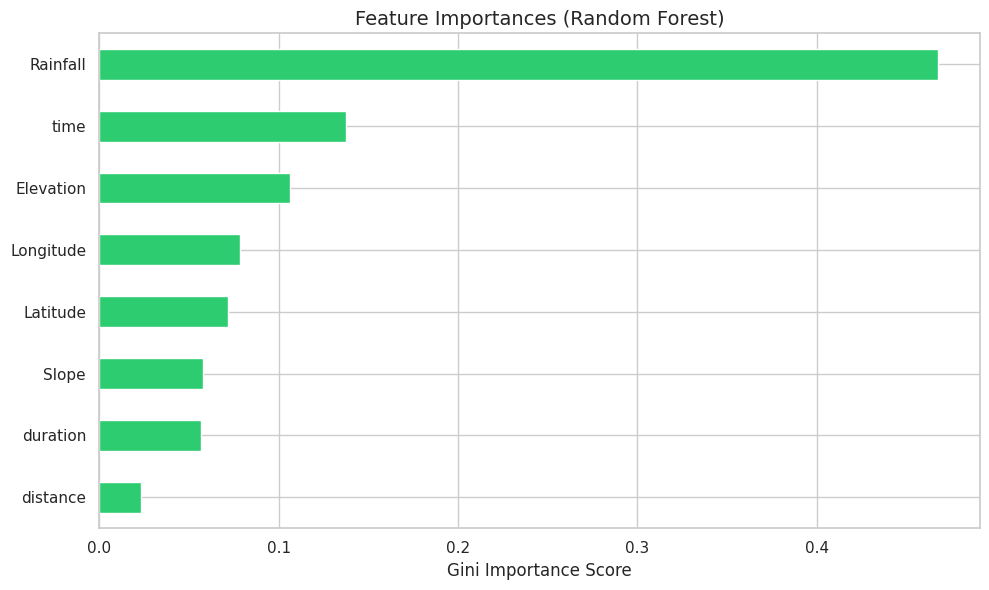


Feature Importance Rankings:
Rainfall     0.467715
time         0.137521
Elevation    0.106296
Longitude    0.078696
Latitude     0.072010
Slope        0.057942
duration     0.056643
distance     0.023177
dtype: float64

Saved 'Random Forest' as 'best_model.pkl' for application deployment.


In [10]:
# ==========================================================
# FLOOD RISK CATEGORY CLASSIFICATION - MODEL TRAINING & EVALUATION
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

print("--- Step 1: Loading Preprocessed Splits & Scaler ---")
X_train = pd.read_csv('X_train_scaled.csv')
X_test = pd.read_csv('X_test_scaled.csv')
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()
scaler = joblib.load('scaler.pkl')

print("Data successfully re-loaded:")
print(f"  Training samples: {X_train.shape[0]} | Testing samples: {X_test.shape[0]}\n")

# ----------------------------------------------------------
# 2. MODEL INITIALIZATION & TRAINING
# ----------------------------------------------------------
print("--- Step 2: Training Foundational Models ---")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=6),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
}

results = []
trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_proba

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# Convert results into a clean summary table
results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n" + "="*60)
print("MODEL EVALUATION COMPARISON TABLE")
print("="*60)
display(results_df.style.highlight_max(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], color='lightgreen'))

# ----------------------------------------------------------
# 3. CONFUSION MATRICES VISUALIZATION
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Flood (0)', 'Flood (1)'],
                yticklabels=['No Flood (0)', 'Flood (1)'])
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4. ROC CURVES COMPARISON
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))

for name, y_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_proba):.4f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)')
plt.title('Receiver Operating Characteristic (ROC) Curves', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ----------------------------------------------------------
# 5. FEATURE IMPORTANCE INTERPRETATION (RANDOM FOREST)
# ----------------------------------------------------------
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"\n--- Best Performing Model: {best_model_name} ---")

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

    plt.figure(figsize=(10, 6))
    importances.plot(kind='barh', color='#2ecc71')
    plt.title(f'Feature Importances ({best_model_name})', fontsize=14)
    plt.xlabel('Gini Importance Score')
    plt.tight_layout()
    plt.show()

    print("\nFeature Importance Rankings:")
    print(importances.sort_values(ascending=False))

# ----------------------------------------------------------
# 6. SAVE BEST MODEL ARTIFACT FOR STREAMLIT APP
# ----------------------------------------------------------
joblib.dump(best_model, 'best_model.pkl')
print(f"\nSaved '{best_model_name}' as 'best_model.pkl' for application deployment.")